
# European Option: Monte Carlo Convergence Study

This notebook runs a convergence and confidence-interval calibration study for **European call/put** options where the Black-Scholes value is known in closed form.

It performs a path-count sweep over log-spaced $N$ (for example $10^3$ to $10^6$) and produces:

1. Absolute pricing error $|\hat{V}_{MC} - V_{BS}|$ vs $N$ on log-log axes.
2. Reported Monte Carlo standard error vs $N$ on log-log axes, with an $N^{-1/2}$ reference slope.

The expected high-level behavior is:
- Error and standard error decay approximately as $N^{-1/2}$.


In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.bs_analytics import bs_price
from src.gbm import simulate_gbm_paths
from src.mc import mc_price_european
from src.rng import RNG

## Parameters

Adjust `n_grid` and `n_replications` here; nothing else needs to change to re-run the study at a different scale. Increasing `n_replications` gives smoother mean-error curves at the cost of longer runtime.

In [2]:
S0, K, r, T, sigma = 100.0, 100.0, 0.02, 1.0, 0.25
n_grid = np.unique(np.logspace(3, 6.5, num=8).astype(int))
n_replications = 30
master_seed = 20260215

## Sweep Function

`run_sweep` runs `n_replications` independent MC estimates at each N in `n_grid`. For each replication it prices both call and put from the same terminal-price sample, then records the absolute error against the Black-Scholes closed form and the reported standard error. Multiple replications per N give stable mean estimates rather than a single noisy point.

In [3]:
def run_sweep(
    S0=100.0,
    K=100.0,
    r=0.02,
    T=1.0,
    sigma=0.25,
    n_grid=None,
    n_replications=30,
    master_seed=20260215,
):
    """Run log-space N sweep and aggregate convergence diagnostics.

    For each option type (call/put) and each N in the grid, this function runs
    many independent replications and records:
    - absolute pricing error vs Black-Scholes truth,
    - reported Monte Carlo standard error.

    Parameters
    ----------
    n_grid : array-like or None
        Path counts N to sweep. If None, defaults to logspace(1e3..1e6.5).
    n_replications : int
        Independent runs per N used for stable mean error/stderr estimates.
    master_seed : int
        Seed for generating replication-level seeds.

    Returns
    -------
    dict
        Nested structure with experiment config, BS truths, raw rep data,
        and aggregated summary statistics suitable for plotting.
    """
    if n_grid is None:
        n_grid = np.unique(np.logspace(3, 6.5, num=8).astype(int))

    option_types = ["call", "put"]

    seed_rng = np.random.default_rng(master_seed)

    bs_truth = {opt: bs_price(S0, K, T, r, sigma, opt) for opt in option_types}

    raw = {
        opt: {int(N): {"abs_error": [], "stderr": []} for N in n_grid}
        for opt in option_types
    }

    for N in n_grid:
        rep_seeds = seed_rng.integers(
            low=1,
            high=2**31 - 1,
            size=n_replications,
            dtype=np.int64,
        )

        for seed in rep_seeds:
            rng = RNG(seed=int(seed))
            paths = simulate_gbm_paths(
                S0=S0, r=r, sigma=sigma, T=T, steps=1, n_paths=int(N), rng=rng
            )
            terminal_prices = paths[:, -1]

            for opt in option_types:
                result = mc_price_european(terminal_prices, K, r, T, opt)
                abs_error = abs(result["price"] - bs_truth[opt])
                raw[opt][int(N)]["abs_error"].append(abs_error)
                raw[opt][int(N)]["stderr"].append(result["stderr"])

    summary = {
        opt: {"N": [], "mean_abs_error": [], "mean_stderr": []}
        for opt in option_types
    }

    for opt in option_types:
        for N in n_grid:
            abs_error_arr = np.asarray(raw[opt][int(N)]["abs_error"], dtype=float)
            stderr_arr = np.asarray(raw[opt][int(N)]["stderr"], dtype=float)
            summary[opt]["N"].append(int(N))
            summary[opt]["mean_abs_error"].append(abs_error_arr.mean())
            summary[opt]["mean_stderr"].append(stderr_arr.mean())

        for key in summary[opt]:
            summary[opt][key] = np.asarray(summary[opt][key], dtype=float)

    return {
        "config": {
            "S0": S0, "K": K, "r": r, "T": T, "sigma": sigma,
            "n_grid": np.asarray(n_grid, dtype=int),
            "n_replications": n_replications,
            "master_seed": master_seed,
        },
        "bs_truth": bs_truth,
        "raw": raw,
        "summary": summary,
    }

## Run the Sweep

Execute the sweep with the parameters defined above. This is the most time-consuming step — runtime scales with `n_replications × len(n_grid)`.

In [4]:
results = run_sweep(
    S0=S0,
    K=K,
    r=r,
    T=T,
    sigma=sigma,
    n_grid=n_grid,
    n_replications=n_replications,
    master_seed=master_seed,
)

## Convergence Plots

The two plots below show mean absolute error and mean standard error against N on log-log axes. Both should decay approximately as N^{-1/2}, visible as a straight line with slope −½ matching the dashed reference line.

In [5]:
def plot_results(results):
    """Produce pricing-error and stderr convergence plots."""
    summary = results["summary"]
    option_types = ["call", "put"]

    # Plot 1: Absolute pricing error vs N (log-log).
    fig, ax = plt.subplots(figsize=(9, 5.5))
    for opt in option_types:
        N = summary[opt]["N"]
        y = summary[opt]["mean_abs_error"]
        ax.loglog(N, y, marker="o", linewidth=2, label=f"{opt.capitalize()} |MC - BS|")
    ax.set_xlabel("Number of Paths N")
    ax.set_ylabel("Mean Absolute Pricing Error")
    ax.set_title("Absolute Pricing Error vs N (log-log)")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    plt.show()
    plt.close(fig)

    # Plot 2: Std error vs N (log-log) with N^{-1/2} reference slope.
    fig, ax = plt.subplots(figsize=(9, 5.5))
    for opt in option_types:
        N = summary[opt]["N"]
        y = summary[opt]["mean_stderr"]
        ax.loglog(N, y, marker="o", linewidth=2, label=f"{opt.capitalize()} mean stderr")

        # Reference curve with exact slope -1/2, anchored at first observed point.
        N0, y0 = N[0], y[0]
        y_ref = y0 * (N / N0) ** (-0.5)
        ax.loglog(N, y_ref, linestyle="--", linewidth=1.5, label=f"{opt.capitalize()} ref slope -1/2")
    ax.set_xlabel("Number of Paths N")
    ax.set_ylabel("Mean Reported Std Error")
    ax.set_title("Monte Carlo Std Error vs N (log-log)")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    plt.show()
    plt.close(fig)

## Interpretation

A slope matching the −½ reference confirms that the reported standard error is well-calibrated and the estimator is unbiased. Systematic upward deviation from the reference slope would indicate variance that decays more slowly than expected (e.g., correlated paths); downward deviation would suggest an unexpectedly efficient estimator or correlation between replications.

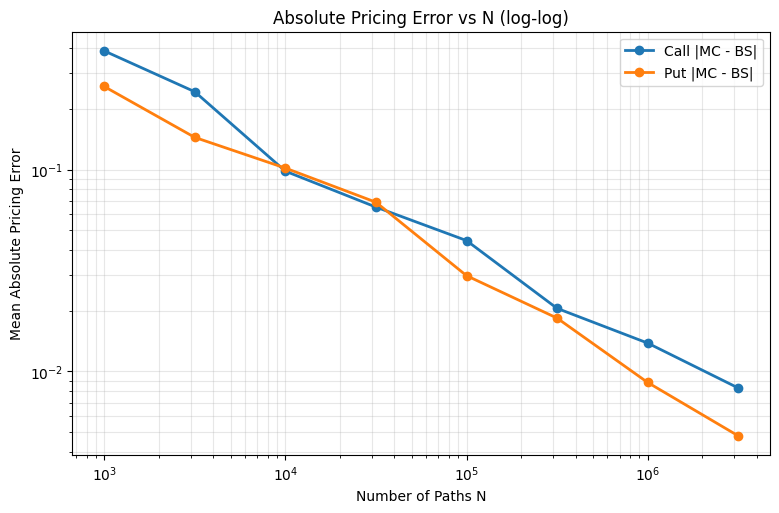

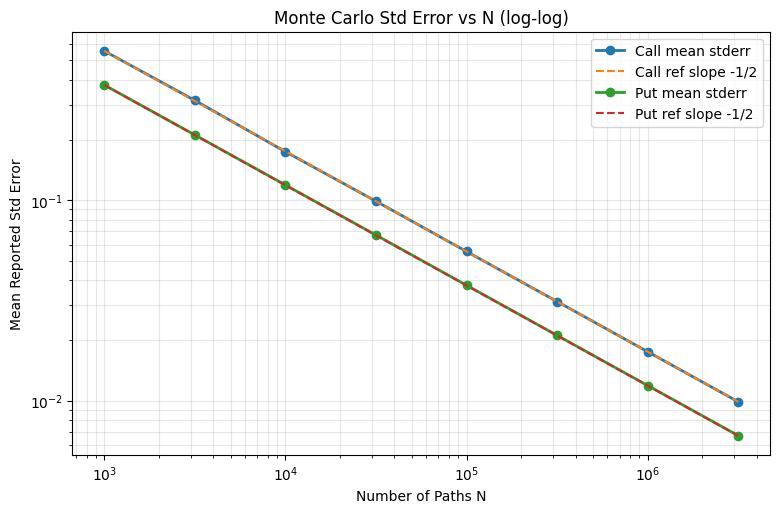

In [6]:
plot_results(results)